## PROJETO 5 - REDES MLP

Dataset utilizado: 

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler


col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "attack_type", "difficulty_level"
]


train_df = pd.read_csv(
    "dataset/KDDTrain+.txt",
    names=col_names
)

test_df = pd.read_csv(
    "dataset/KDDTest+.txt",
    names=col_names
)


print("Treino:")
print(train_df.head())

print("\nTeste:")
print(test_df.head())

Treino:
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2     

1- Com os dados carregados e os nomes de suas colunas atribuidos manualmente, agora será feita a remoção da coluna dificulty_level, a aplicação do *one-hot encoding*, binarizar o rótulo e normalização dos atributos utilizando Z-score no treino.

Remoção da coluna dificulty_level:

In [2]:

train_df.drop("difficulty_level", axis=1, inplace=True)
test_df.drop("difficulty_level", axis=1, inplace=True)

Binarização dos rótulos:

In [3]:
train_df["attack_type"] = train_df["attack_type"].apply(
    lambda x: 0 if x == "normal" else 1
)

test_df["attack_type"] = test_df["attack_type"].apply(
    lambda x: 0 if x == "normal" else 1
)

Aplicando one-hot:

In [4]:
categorical_columns = [
    "protocol_type",
    "service",
    "flag"
]

train_df = pd.get_dummies(
    train_df,
    columns=categorical_columns
)

test_df = pd.get_dummies(
    test_df,
    columns=categorical_columns
)

Normalização dos dados:

In [6]:
train_df, test_df = train_df.align(
    test_df,
    join='left',
    axis=1,
    fill_value=0
)


X_train = train_df.drop("attack_type", axis=1)
y_train = train_df["attack_type"]

X_test = test_df.drop("attack_type", axis=1)
y_test = test_df["attack_type"]

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Verificação da quantidade de ataques entre treino e teste, somente para validar se a separação foi feita corretamente:

In [8]:
print("Formato X_train:", X_train.shape)
print("Formato X_test:", X_test.shape)

print("Quantidade de ataques no treino:")
print(y_train.value_counts())

print("Quantidade de ataques no teste:")
print(y_test.value_counts())

Formato X_train: (125973, 122)
Formato X_test: (22544, 122)
Quantidade de ataques no treino:
attack_type
0    67343
1    58630
Name: count, dtype: int64
Quantidade de ataques no teste:
attack_type
1    12833
0     9711
Name: count, dtype: int64


2- Implementação da MLP utilizando PyTorch:


In [11]:
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

In [12]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

Minibatches:

In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

Classe MLP e modelo instanciado utilizando a função de ativação ReLU:

In [14]:
class MLP(nn.Module):

    def __init__(self, input_size):

        super(MLP, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)

        )

    def forward(self, x):

        return self.network(x)


input_size = X_train.shape[1]

model = MLP(input_size)


criterion = nn.BCEWithLogitsLoss()


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


print(model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=122, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


3- Treinamento do modelo:

In [17]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import torch.optim as optim

Época 1/50 | Loss treino: 0.0843 | Loss validação: 0.0322
Época 2/50 | Loss treino: 0.0277 | Loss validação: 0.0266
Época 3/50 | Loss treino: 0.0210 | Loss validação: 0.0185
Época 4/50 | Loss treino: 0.0180 | Loss validação: 0.0212
Época 5/50 | Loss treino: 0.0167 | Loss validação: 0.0165
Época 6/50 | Loss treino: 0.0151 | Loss validação: 0.0184
Época 7/50 | Loss treino: 0.0141 | Loss validação: 0.0160
Época 8/50 | Loss treino: 0.0132 | Loss validação: 0.0150
Época 9/50 | Loss treino: 0.0127 | Loss validação: 0.0147
Época 10/50 | Loss treino: 0.0123 | Loss validação: 0.0136
Época 11/50 | Loss treino: 0.0116 | Loss validação: 0.0147
Época 12/50 | Loss treino: 0.0111 | Loss validação: 0.0130
Época 13/50 | Loss treino: 0.0116 | Loss validação: 0.0156
Época 14/50 | Loss treino: 0.0106 | Loss validação: 0.0151
Época 15/50 | Loss treino: 0.0101 | Loss validação: 0.0145
Época 16/50 | Loss treino: 0.0101 | Loss validação: 0.0141
Early stopping na época 17


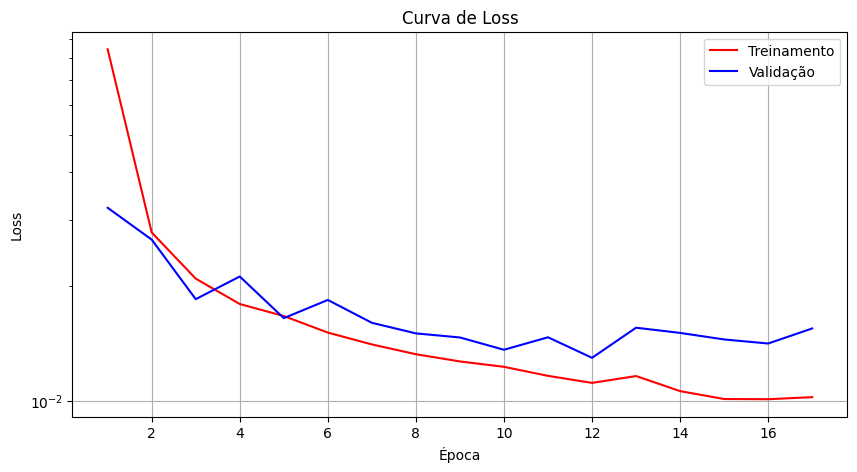

In [20]:
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    shuffle=False
)

X_train_split = torch.tensor(X_train_split, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train_split = torch.tensor(y_train_split.values, dtype=torch.float32)
y_val = torch.tensor(y_val.values, dtype=torch.float32)

train_ds = TensorDataset(X_train_split, y_train_split)

train_loader = DataLoader(
    train_ds,
    batch_size=256,
    shuffle=True
)


model = MLP(input_size=X_train.shape[1])
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


epochs = 50
patience = 5

best_val_loss = np.inf
best_weights = None

train_loss = []
val_loss = []

stop_epoch = epochs
epochs_no_improve = 0


for epoch in range(epochs):

    model.train()
    epoch_train_loss = 0.0

    for batch_X, batch_y in train_loader:

        optimizer.zero_grad()
        outputs = model(batch_X).squeeze()
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()

    train_loss.append(
        epoch_train_loss / len(train_loader)
    )

    model.eval()

    with torch.no_grad():

        val_predictions = model(X_val).squeeze()
        validation_loss = criterion(
            val_predictions,
            y_val
        ).item()

        val_loss.append(validation_loss)


    if val_loss[-1] < best_val_loss:

        best_val_loss = val_loss[-1]
        best_weights = {
            k: v.clone()
            for k, v in model.state_dict().items()
        }

        epochs_no_improve = 0

    else:

        epochs_no_improve += 1

        if epochs_no_improve >= patience:
            stop_epoch = epoch + 1
            print(f"Early stopping na época {stop_epoch}")
            break

    print(
        f'Época {epoch+1}/{epochs} | '
        f'Loss treino: {train_loss[-1]:.4f} | '
        f'Loss validação: {val_loss[-1]:.4f}'
    )


model.load_state_dict(best_weights)
epoch_vector = np.arange(1, len(train_loss)+1)

plt.figure(figsize=(10,5))

plt.semilogy(
    epoch_vector,
    train_loss,
    'r',
    label='Treinamento'
)

plt.semilogy(
    epoch_vector,
    val_loss,
    'b',
    label='Validação'
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de Loss")
plt.grid()
plt.legend()
plt.show()